In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [3]:
# pd.set_option("display.max_columns",None)
df = pd.read_csv("electronics.csv")

In [4]:
df.head()

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,3.0,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0


In [5]:
df.dtypes

item_id         int64
user_id         int64
rating        float64
timestamp      object
model_attr     object
category       object
brand          object
year            int64
user_attr      object
split           int64
dtype: object

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [8]:
df.dtypes

item_id                int64
user_id                int64
rating               float64
timestamp     datetime64[ns]
model_attr            object
category              object
brand                 object
year                   int64
user_attr             object
split                  int64
dtype: object

In [9]:
df['rating'] = pd.to_numeric(df['rating'])

In [10]:
df.dtypes

item_id                int64
user_id                int64
rating               float64
timestamp     datetime64[ns]
model_attr            object
category              object
brand                 object
year                   int64
user_attr             object
split                  int64
dtype: object

In [11]:
df.isna()

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,False,False,False,False,False,False,True,False,True,False
1,False,False,False,False,False,False,True,False,True,False
2,False,False,False,False,False,False,True,False,True,False
3,False,False,False,False,False,False,True,False,True,False
4,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...
1292949,False,False,False,False,False,False,False,False,True,False
1292950,False,False,False,False,False,False,True,False,True,False
1292951,False,False,False,False,False,False,True,False,True,False
1292952,False,False,False,False,False,False,True,False,True,False


In [12]:
df.isna().sum()

item_id             0
user_id             0
rating              0
timestamp           0
model_attr          0
category            0
brand          961834
year                0
user_attr     1118830
split               0
dtype: int64

In [14]:

df2 = df.copy()

df2.loc[0:5, 'rating'] = np.nan

In [15]:
df2.isna().sum()

item_id             0
user_id             0
rating              6
timestamp           0
model_attr          0
category            0
brand          961834
year                0
user_attr     1118830
split               0
dtype: int64

In [16]:
df2.head(10)

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,NaN,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,NaN,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,NaN,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,NaN,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,NaN,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0
5,0,5,NaN,1999-07-12,Female,Portable Audio & Video,NaN,1999,NaN,0
6,0,6,5.0,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
7,0,7,2.0,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
8,0,8,4.0,1999-07-16,Female,Portable Audio & Video,NaN,1999,NaN,0
9,0,9,5.0,1999-08-20,Female,Portable Audio & Video,NaN,1999,NaN,0


In [17]:
df_remove = df2.dropna()

In [18]:
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)

df with NaN:  (1292954, 10)
df without NaN:  (45166, 10)


In [19]:
df_remove.isna().sum()

item_id       0
user_id       0
rating        0
timestamp     0
model_attr    0
category      0
brand         0
year          0
user_attr     0
split         0
dtype: int64

In [20]:

df_mean = df2.copy()

df_mean['rating'] = df_mean['rating'].fillna(df_mean['rating'].mean())

In [21]:
df_mean.head(10)

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,4.051487,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,4.051487,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,4.051487,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,4.051487,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,4.051487,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0
5,0,5,4.051487,1999-07-12,Female,Portable Audio & Video,NaN,1999,NaN,0
6,0,6,5.000000,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
7,0,7,2.000000,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
8,0,8,4.000000,1999-07-16,Female,Portable Audio & Video,NaN,1999,NaN,0
9,0,9,5.000000,1999-08-20,Female,Portable Audio & Video,NaN,1999,NaN,0


Task 2: I used Median Imputation to fill the missing rating values. In an electronics dataset, ratings are often skewed by extreme reviews (1s or 5s). The median is a better choice than the mean because it represents the "typical" user experience without being distorted by those outliers.

In [23]:
df_median = df2.copy()
# Create a copy for the median imputation exercise
df_median = df2.copy()

# Fill missing ratings with the median value
df_median['rating'] = df_median['rating'].fillna(df_median['rating'].median())

In [24]:
df_median.head(10)

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,5.0,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,5.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,5.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0
5,0,5,5.0,1999-07-12,Female,Portable Audio & Video,NaN,1999,NaN,0
6,0,6,5.0,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
7,0,7,2.0,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
8,0,8,4.0,1999-07-16,Female,Portable Audio & Video,NaN,1999,NaN,0
9,0,9,5.0,1999-08-20,Female,Portable Audio & Video,NaN,1999,NaN,0


In [25]:
import matplotlib.pyplot as plt

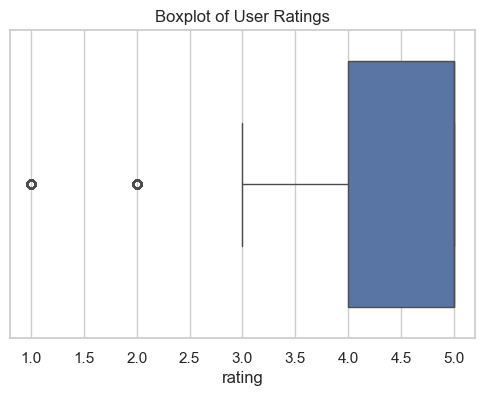

In [26]:

plt.figure(figsize=(6,4))

sns.boxplot(x=df['rating'])

# Add a descriptive title
plt.title('Boxplot of User Ratings')

# Display the plot
plt.show()

Task 3: I used the IQR method to mathematically define outliers. By calculating the "fences" at 1.5×IQR, I can accurately identify products with ratings that are statistically unusual compared to the rest of the dataset.

In [28]:
Q1 = df['rating'].quantile(0.25)
Q3 = df['rating'].quantile(0.75)
IQR = Q3 - Q1


lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


outliers = df[(df['rating'] < lower) | (df['rating'] > upper)]

outliers.head(15)

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0
5,0,5,2.0,1999-07-12,Female,Portable Audio & Video,NaN,1999,NaN,0
7,0,7,2.0,1999-07-13,Female,Portable Audio & Video,NaN,1999,NaN,0
10,0,10,1.0,1999-08-24,Female,Portable Audio & Video,NaN,1999,NaN,0
11,0,11,1.0,1999-10-04,Female,Portable Audio & Video,NaN,1999,NaN,0
18,0,18,1.0,1999-11-06,Female,Portable Audio & Video,NaN,1999,NaN,0
22,0,22,1.0,1999-11-23,Female,Portable Audio & Video,NaN,1999,NaN,0
28,0,28,2.0,1999-12-01,Female,Portable Audio & Video,NaN,1999,Female,0
29,0,29,2.0,1999-12-02,Female,Portable Audio & Video,NaN,1999,NaN,0


In [29]:
df_no_outliers = df[(df['rating'] >= lower) & (df['rating'] <= upper)]

print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (1292954, 10)
df without outliers:  (1070551, 10)


In [30]:
lower_cap = df['rating'].quantile(0.05) # 5%
upper_cap = df['rating'].quantile(0.95) # 95%

df_capped = df.copy()
df_capped['rating'] = df_capped['rating'].clip(lower_cap, upper_cap)

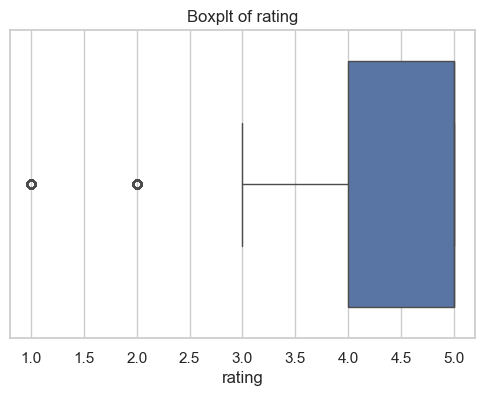

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['rating'])

plt.title('Boxplt of rating')
plt.show()

In [32]:

df[['rating', 'split']].head()

,rating,split
0,5.0,0
1,5.0,0
2,3.0,0
3,1.0,0
4,2.0,0


Task 4: I applied Min,Max Scaling to squash the rating and split columns into a 0 to 1 range, ensuring no single feature dominates the model due to its scale. I also used Z-score Standardization to center the data around a mean of 0, which is essential for algorithms like PCA.

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Create a copy for the scaled data
df_scaled = df[['rating', 'split']].copy()

# Apply the fit_transform to scale values between 0 and 1
df_scaled[['rating', 'split']] = scaler.fit_transform(df_scaled)

# View the normalized results
df_scaled.head()

,rating,split
0,1.00,0.0
1,1.00,0.0
2,0.50,0.0
3,0.00,0.0
4,0.25,0.0


In [34]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Create a copy for the standardized data
df_standardized = df[['rating', 'split']].copy()

# Apply the transformation
df_standardized[['rating', 'split']] = scaler.fit_transform(df_standardized)

# View the result
df_standardized.head()

,rating,split
0,0.687465,-0.31735
1,0.687465,-0.31735
2,-0.762092,-0.31735
3,-2.211649,-0.31735
4,-1.486870,-0.31735


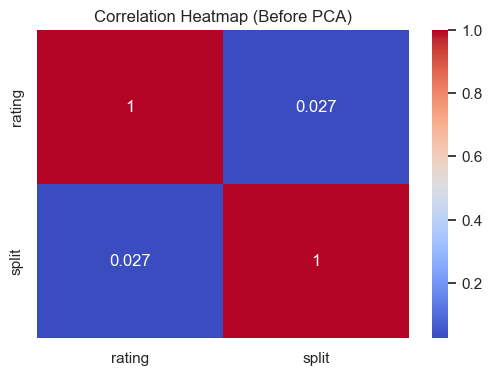

In [35]:
# Set the figure size
plt.figure(figsize=(6,4))

# Create the heatmap using your standardized columns: 'rating' and 'split'
sns.heatmap(df_standardized[['rating', 'split']].corr(), 
            annot=True, 
            cmap="coolwarm")

# Update the title to be descriptive
plt.title("Correlation Heatmap (Before PCA)")

# Display the plot
plt.show()

Task 5: Before running PCA, I used a Correlation Heatmap to check if the features were related. PCA then transformed these correlated variables into Principal Components. The Explained Variance Ratio shows exactly how much of the original data's information is captured by each new component.

In [36]:
from sklearn.decomposition import PCA

# Select your standardized numerical features
X = df_standardized[['rating', 'split']]

# Initialize PCA to find 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Print how much information each component holds
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.51328736 0.48671264]


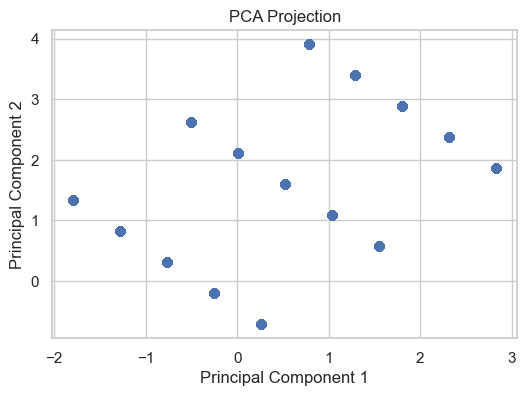

In [37]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()